# Fashion Micro-Trend Lifecycle Modeler

## Overview
This project models the lifecycle of fashion micro-trends using data from Google Trends. Each trend is treated as a curve with a birth, peak, and death. My goal is to quantify the speed at which these microtrends rise and fall, and also whether varying types of trends follow different patterns.

## Data Source
- **Google Trends** via pytrends Python library
- Weekly search interest scores (0-100) over a span of 5 years (2021-2026)
- 10 fashion micro-trends analyzed

## Methology
Each trend's time series was fit to a log-normal curve using scipy's curve_fit function. Three parameters were extracted per trend:
- **Amplitude** - how high the peak reached
- **Sigma** - how wide/narrow the curve is (small sigma means sharper spike)
- **R^2** - how well the log-normal graph fits the real data 

## Findings

### 1. Not all trends follow a log-normal lifecycle
6 of the 10 trends were successfully fitted. The 4 that failed can be sorted into two categories:
- **Still growing**: old money, clean girl, Y2K - no clear decay yet
- **Too flat**: balletcore - likely a Tiktok-native trend with minimal Google searchs

### 2. Brat summer had the cleanest lifecycle
With an R^2 value of 0.828, brat summer most closely followed a log-normal curve with a sharp music-driven spike in July 2024 followed by rapid decay within weeks.

### 3. Peak intensity and half-life appear unrelated
Trends that hit 100/100 on Google Trends (coquette, brat summer) died just as fast as trends that peaked much lower. Greater virality does not imply longevity.

### 4. Google Trends undercounts Tiktok-native trends
Trends with self-explanatory names (old money, clean girl, ballet core) show lower Google search interest relative to their actual cultural reach, since audiences consume them on Tiktok without the need to search them on Google.

### Limitations
- Google Trends data is normalized (0-100) and relative, not absolute search volume
- Tikotk lifecycle data was unavailable, the Tiktok Research API would allow for more complete analysis in future work
- Sample size of 10 trends is small so conclusions are directional and not wholly definitive

## Tools Used
Python, pandas, pytrends, scipy, matplotlib, plotly

c:\Users\cinna\AppData\Local\Programs\Python\Python310\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
c:\Users\cinna\AppData\Local\Programs\Python\Python310\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


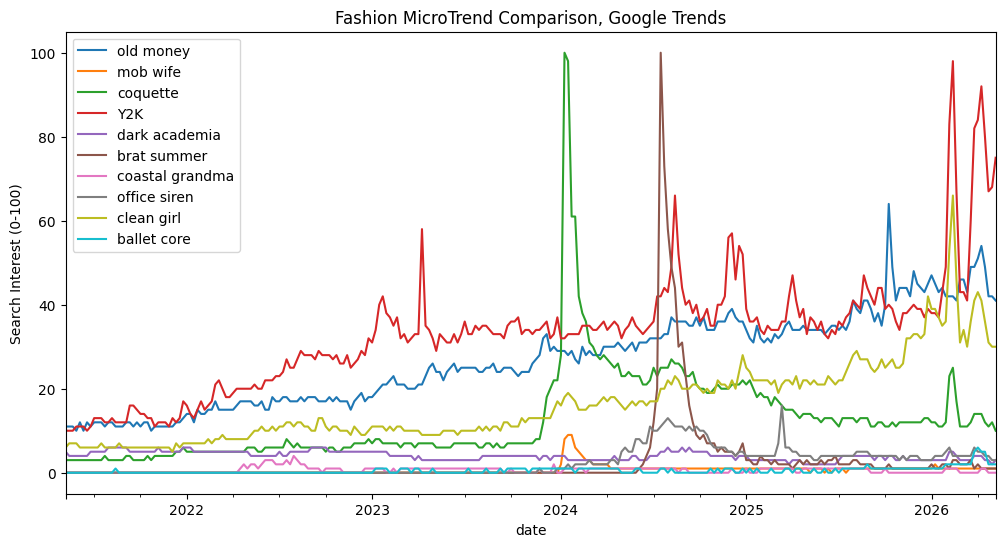

old money: peaked on Oct 2025 at 64/100
mob wife: peaked on Jan 2024 at 9/100
coquette: peaked on Jan 2024 at 100/100
Y2K: peaked on Feb 2026 at 98/100
dark academia: peaked on Aug 2021 at 6/100
brat summer: peaked on Jul 2024 at 100/100
coastal grandma: peaked on Jul 2022 at 4/100
office siren: peaked on Mar 2025 at 16/100
clean girl: peaked on Feb 2026 at 66/100
ballet core: peaked on Apr 2026 at 6/100
                 peak_value  peak_date  weeks_to_peak  weeks_to_halflife
trend                                                                   
old money                64 2025-10-12            231                NaN
mob wife                  9 2024-01-21            141                4.0
coquette                100 2024-01-14            140                4.0
Y2K                      98 2026-02-15            249                2.0
dark academia             6 2021-08-01             12               86.0
brat summer             100 2024-07-21            167                3.0
coastal 

In [3]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

pytrends = TrendReq(hl='en-US', tz=360)
kw_list = ['old money',
           'mob wife',
           'coquette',
           'Y2K',
           'dark academia']

kw_list2 = ['brat summer',
           'coastal grandma',
           'office siren',
           'clean girl',
           'ballet core']

pytrends.build_payload(kw_list, timeframe='today 5-y')
df1 = pytrends.interest_over_time()
df1 = df1.drop(columns=['isPartial'])
pytrends.build_payload(kw_list2, timeframe='today 5-y')
df2 = pytrends.interest_over_time().drop(columns=['isPartial'])

df = df1.join(df2)

df.plot(figsize=(12, 6), title='Fashion MicroTrend Comparison, Google Trends')
plt.ylabel('Search Interest (0-100)')
plt.show()

df.to_csv('trends_raw.csv')
df = pd.read_csv('trends_raw.csv', index_col=0, parse_dates=True)


for trend in df.columns:
    peak_date = df[trend].idxmax()
    peak_value = df[trend].max()
    print(f"{trend}: peaked on {peak_date.strftime('%b %Y')} at {peak_value}/100")

metrics = []
for trend in df.columns:
    series = df[trend]

    peak_value = series.max()
    peak_date = series.idxmax()

    post_peak = series[peak_date:]
    half_life_rows = post_peak[post_peak <= peak_value * 0.5]

    if not half_life_rows.empty:
        half_life_date = half_life_rows.index[0]
    else:
        half_life_date = None

    if half_life_date is not None:
        weeks_to_halflife = (half_life_date - peak_date).days // 7
    else:
        weeks_to_halflife = None

    weeks_to_peak = (peak_date - series.index[0]).days // 7

    metrics.append({
        'trend': trend,
        'peak_value': peak_value,
        'peak_date': peak_date,
        'weeks_to_peak': weeks_to_peak,
        'weeks_to_halflife': weeks_to_halflife
    })

metrics_df = pd.DataFrame(metrics).set_index('trend')
print(metrics_df)

scatter_df = metrics_df.dropna(subset=['weeks_to_halflife'])
scatter_df = metrics_df[metrics_df['peak_value'] >= 20].dropna(subset=['weeks_to_halflife'])

fig = px.scatter(
    scatter_df,
    x='weeks_to_halflife',
    y='peak_value',
    text=scatter_df.index,
    title='Trend Intensity vs Longevity',
    labels={
        'weeks_to_halflife': 'Weeks to Half-Life (how fast it died)',
        'peak_value': 'Peak Intensity (0-100)'
    }
)

fig.update_traces(textposition='top center')
fig.show()


                 amplitude  sigma  r_squared  \
trend                                          
ballet core            NaN    NaN        NaN   
old money              NaN    NaN        NaN   
mob wife              8.50   0.02      0.574   
coquette             26.49   0.28      0.407   
Y2K                    NaN    NaN        NaN   
dark academia         5.35   3.20      0.389   
brat summer          69.55   0.02      0.828   
coastal grandma       2.68   0.13      0.012   
office siren          7.43   0.19      0.714   
clean girl             NaN    NaN        NaN   
ballet core            NaN    NaN        NaN   
old money              NaN    NaN        NaN   
mob wife              8.50   0.02      0.574   
coquette             26.49   0.28      0.407   
Y2K                    NaN    NaN        NaN   
dark academia         5.35   3.20      0.389   
brat summer          69.55   0.02      0.828   
coastal grandma       2.68   0.13      0.012   
office siren          7.43   0.19      0

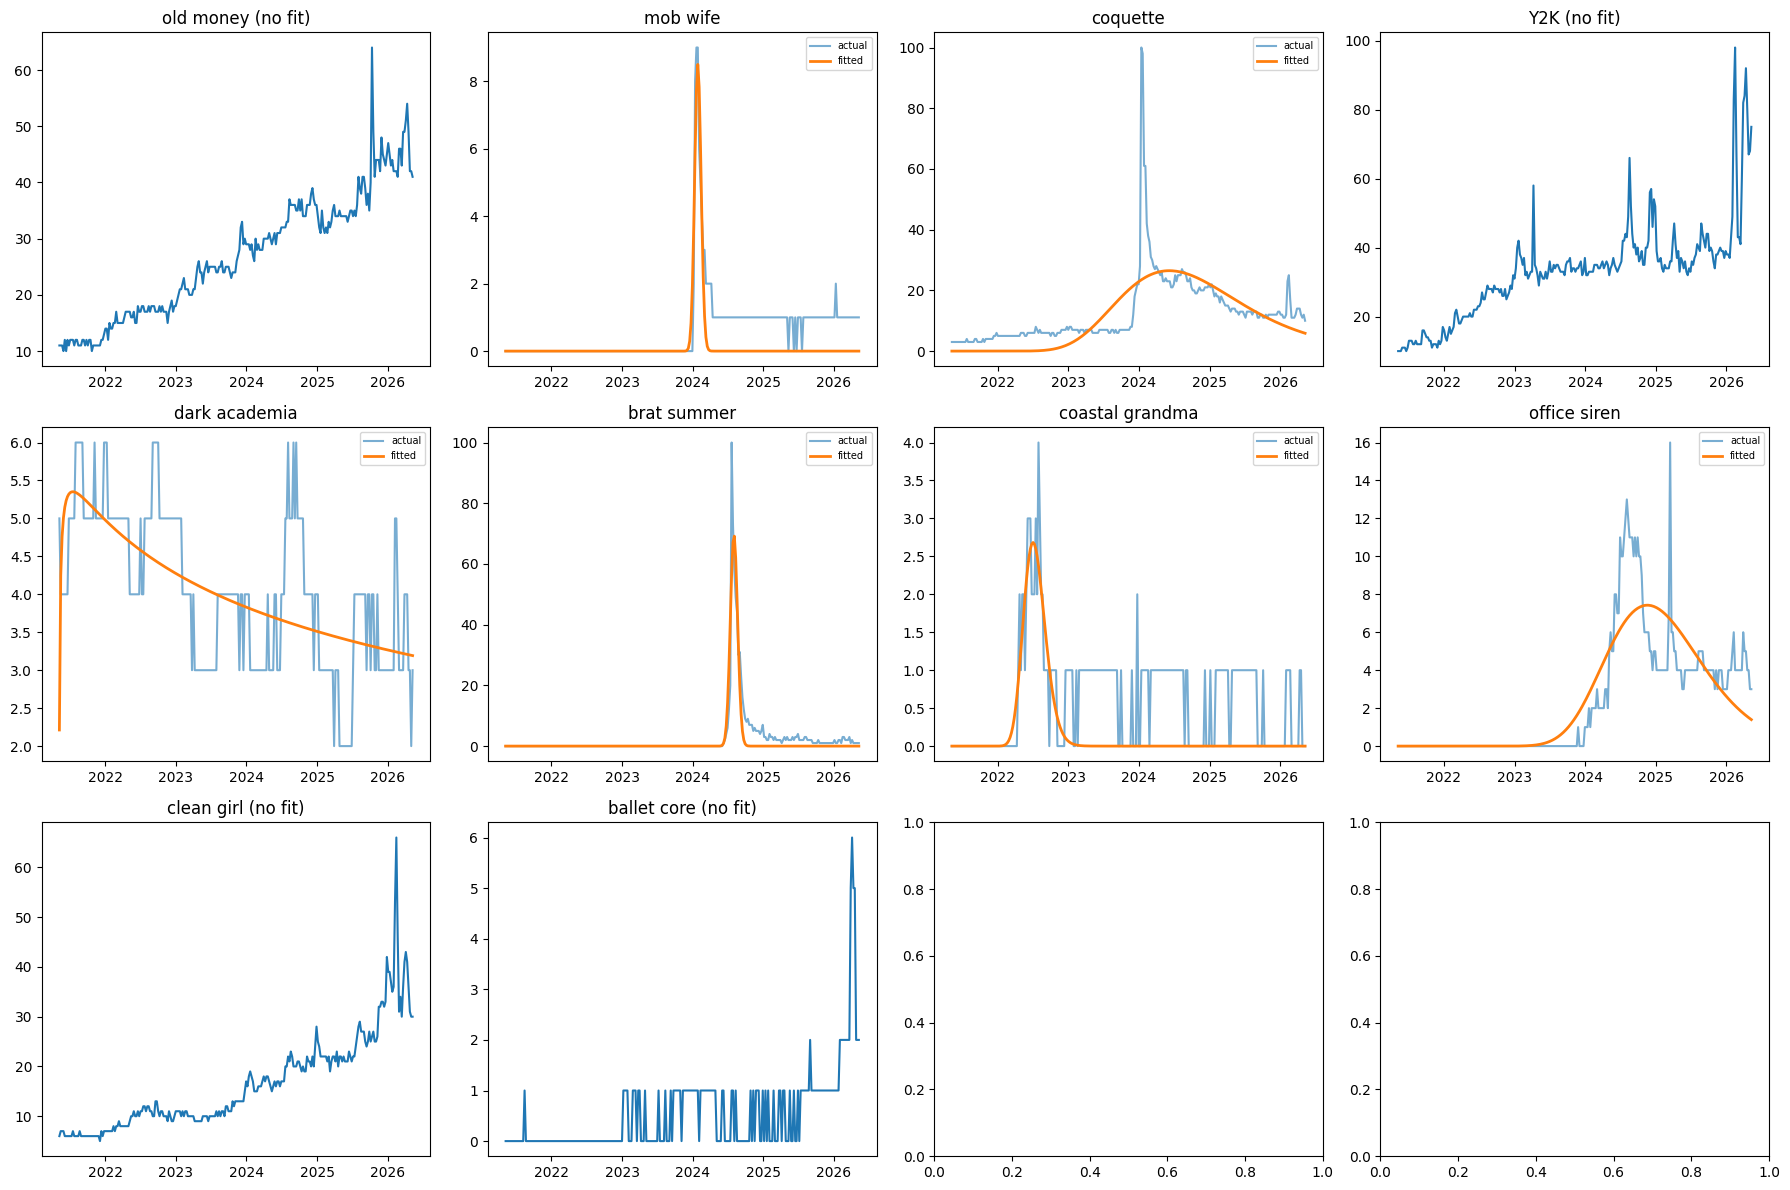

In [10]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import norm

def dates_to_number(series):
    return np.array((series.index - series.index[0]).days, dtype=float)

def lognormal_curve(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((np.log(x + 1) - mean) ** 2) / (2 * sigma ** 2))

for trend in df.columns:
    series = df[trend].dropna()
    x = dates_to_number(series)
    y = series.values.astype(float)
    
    fitted = False
    
    # Try different sigma guesses from narrow to wide
    for sigma_guess in [0.1, 0.3, 0.5, 1.0, 2.0]:
        try:
            p0 = [y.max(), np.log(x[y.argmax()] + 1), sigma_guess]
            params, _ = curve_fit(lognormal_curve, x, y, p0=p0, maxfev=10000)
            
            amplitude, mean, sigma = params
            y_pred = lognormal_curve(x, *params)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot)
            
            fit_results.append({
                'trend': trend,
                'amplitude': round(amplitude, 2),
                'sigma': round(sigma, 2),
                'r_squared': round(r_squared, 3),
                'status': 'fitted'
            })
            fitted = True
            break  # stop trying sigma values once one works
            
        except RuntimeError:
            continue  # try next sigma value
    
    if not fitted:
        fit_results.append({
            'trend': trend,
            'amplitude': None,
            'sigma': None,
            'r_squared': None,
            'status': 'no fit - still growing or too flat'
        })

fit_df = pd.DataFrame(fit_results).set_index('trend')
print(fit_df)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, trend in enumerate(df.columns):
    if i >= len(axes):
        break
        
    series = df[trend].dropna()
    x = dates_to_number(series)
    y = series.values.astype(float)
    
    fitted = False
    for sigma_guess in [0.1, 0.3, 0.5, 1.0, 2.0]:
        try:
            p0 = [y.max(), np.log(x[y.argmax()] + 1), sigma_guess]
            params, _ = curve_fit(lognormal_curve, x, y, p0=p0, maxfev=10000)
            y_fitted = lognormal_curve(x, *params)
            
            axes[i].plot(series.index, y, label='actual', alpha=0.6)
            axes[i].plot(series.index, y_fitted, label='fitted', linewidth=2)
            axes[i].set_title(trend)
            axes[i].legend(fontsize=7)
            fitted = True
            break
        except RuntimeError:
            continue
    
    if not fitted:
        axes[i].plot(series.index, y)
        axes[i].set_title(f'{trend} (no fit)')

plt.tight_layout()
plt.show()

